<a href="https://colab.research.google.com/github/tinawanggg/Wang_DSPN_S26/blob/master/book/exercises/11_the-beauty-of-knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 11: The beauty of kNN

In this exercise, you'll gain practice working with kNN. We'll use the [diamonds](https://ggplot2.tidyverse.org/reference/diamonds.html) dataset, which comes as part of `ggplot2`. This dataset provides information on the quality and price of 50,000 diamonds.


-----
## 1. Data, Plotting, and Train/Test Sets (2 points)
* Load the the `class` and `tidyverse` packages.
* Assign the `diamonds` data set to a simpler name. Then, create a new variable `price_bin` that splits the `price` variable into a binary variable, where 1 indicates that the diamond costs greater than the mean price, and 0 indicates that the diamond costs less than the mean price. Set `price_bin` to be a factor. (*Hint: use the if_else() function*)
* Select just the `carat`, `depth`, `table`, `x`, `y`, and your new `price_bin` variables
* Print the first few lines of the data set
* Print the dimensions of the data set


In [1]:
# INSERT CODE HERE
library(class)
library(tidyverse)

dia <- diamonds
dia$price_bin <- if_else(dia$price > mean(dia$price), 1, 0)

dia <- select(dia, carat, depth, table, x, y, price_bin)
head(dia)

dim(dia)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.23,61.5,55,3.95,3.98,0
0.21,59.8,61,3.89,3.84,0
0.23,56.9,65,4.05,4.07,0
0.29,62.4,58,4.20,4.23,0
0.31,63.3,58,4.34,4.35,0
0.24,62.8,57,3.94,3.96,0


[1] 53940     6

### Plot
Create a scatterplot of the link between `carat` and `depth`, and use the `color` aesthetics mapping to differentiate between diamonds that cost above versus below the mean price.

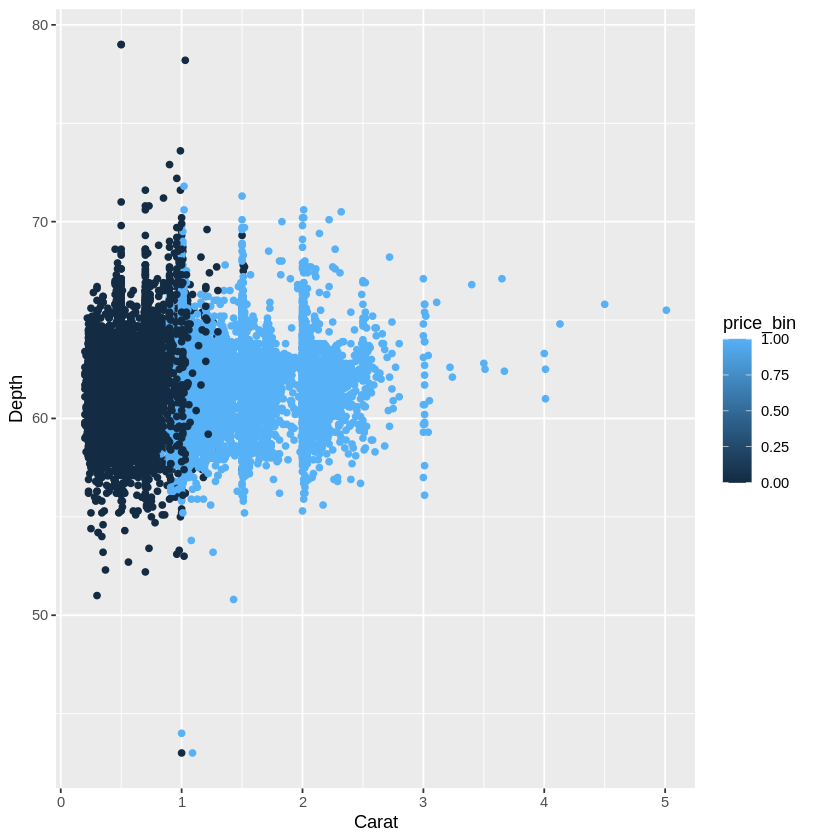

In [2]:
# INSERT CODE HERE
ggplot(dia, aes(x = carat, y = depth, color = price_bin)) +
  geom_point() +
  labs(x = "Carat", y = "Depth")

Based on the above scatterplot, how do you think kNN will perform using only these two variables to predict the price? Which variable, carat or depth, gives us the most information about which price class the diamond will belong to?
> * *The kNN will likely do reasonably well using only these two variables. The carat variable seems strongly defined enough so that the kNN should be able to make a rough decision boundary around the ~1 carat mark.*
>
> * *The carat variable gives more information about diamond price classes. There is a fairly clean horizontal separation along the x-axis at ~1 carat, while the two price classes are thoroughly mixed across the depth range (y-axis).*


### Test vs Train

Before we run KNN on these data, we need to set aside a portion of the observations as our test set. Below, randomly divide the data such that 30% are allotted to the `test` set and the rest are allotted to the `train` set. Print the first few lines of each set, and print the dimensions of each set to double check your division of the data.

In [4]:
set.seed(2023)

# INSERT CODE HERE
test.inds <- sample(1:nrow(dia), round(0.3 * nrow(dia)))

dia$is.test <- 1:nrow(dia) %in% test.inds

test <- dia[dia$is.test == TRUE, ]
train <- dia[dia$is.test == FALSE, ]

head(test)
head(train)

dim(test)
dim(train)

carat,depth,table,x,y,price_bin,is.test
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
0.21,59.8,61,3.89,3.84,0,TRUE
0.30,64.0,55,4.25,4.28,0,TRUE
0.30,62.0,54,4.31,4.34,0,TRUE
0.30,63.4,54,4.23,4.29,0,TRUE
0.30,62.7,59,4.21,4.27,0,TRUE
0.23,63.8,55,3.85,3.92,0,TRUE


carat,depth,table,x,y,price_bin,is.test
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
0.23,61.5,55,3.95,3.98,0,FALSE
0.23,56.9,65,4.05,4.07,0,FALSE
0.29,62.4,58,4.20,4.23,0,FALSE
0.31,63.3,58,4.34,4.35,0,FALSE
0.24,62.8,57,3.94,3.96,0,FALSE
0.24,62.3,57,3.95,3.98,0,FALSE


[1] 16182     7

[1] 37758     7

-----
## 2. KNN (3 points)
Now, use the `knn()` function from the `class` library to predict `price_bin` from the `carat` and `depth`. Set `k = 3`.

*Hint: Review the format required for the arguments of knn()*

In [10]:
set.seed(2023)
# INSERT CODE HERE
train.X <- train[, c("carat", "depth")]
test.X <- test[, c("carat", "depth")]
train.y <- train$price_bin
knn.preds <- knn(train.X, test.X, train.y, k = 3)
knn.preds

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
   [37] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   [73] 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [109] 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
  [145] 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
  [181] 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
  [217] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1
  [253] 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0
  [289] 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
  [325] 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [361] 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
  [397] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [433] 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0
  [469] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [505] 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [541] 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1
  [577] 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0
  [613] 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0
  [649] 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0
  [685] 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0
  [721] 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
  [757] 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1
  [793] 0 0 1 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0
  [829] 0 1 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 1 1 0 0
  [865] 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0
  [901] 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0
  [937] 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0
  [973] 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 0
 [1009] 0 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0
 [1045] 1 1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 0 0
 [1081] 0 0 0 1 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 1
 [1117] 1 1 1 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1 0 0 1 1 1 0 0 1 0 1 0
 [1153] 0 0 1 0 1 1 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0
 [1189] 0 0 1 1 1 1 0 0 1 0 1 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 1 0
 [1225] 0 0 1 0 1 0 0 1 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 0 0 0 1 1 1
 [1261] 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 1 0 0 1
 [1297] 1 1 1 1 0 1 1 1 0 0 1 1 1 1 0 0 0 1 1 1 0 1 0 1 1 0 0 1 0 1 0 0 0 1 1 1
 [1333] 1 0 0 0 0 1 1 1 1 1 0 1 1 1 0 1 0 0 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0
 [1369] 0 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 1 1 1 0 0 1 1 0 1 0 0 1 0 0 0 0 1 1 1 0
 [1405] 1 1 1 1 1 0 0 1 0 0 0 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 0 1 1 1 0
 [1441] 1 1 0 0 1 1 1 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 1 1 0 0 0 0 0 0 1 0 1 0
 [1477] 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1 0
 [1513] 0 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 1 0 0 1 0 1 0 1 0 1 1 1 0 1 0 0 0 1 1 0
 [1549] 1 0 1 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 1 0 0
 [1585] 1 0 0 1 1 1 0 0 1 0 1 0 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 [1621] 1 1 1 1 1 1 1 0 0 1 1 0 1 1 1 0 1 1 0 1 1 1 0 1 1 0 0 1 0 1 0 1 1 0 0 0
 [1657] 1 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1 1 1 1 1 1 1 0 1 1 1
 [1693] 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 0 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1
 [1729] 0 1 1 1 1 0 0 0 1 1 1 0 0 1 0 1 0 0 1 0 1 1 0 0 0 1 1 0 1 1 1 0 1 0 0 0
 [1765] 1 1 1 1 1 1 0 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 1 0 0 1 1 1
 [18

Now, output a confusion matrix and calculate the test error to evaluate model performance.

In [12]:
# INSERT CODE HERE
confusion_matrix <- table(Predicted = knn.preds, Actual = test$price_bin)
confusion_matrix

test.error <- mean(knn.preds != test$price_bin)
cat("Test Error:", test.error)

         Actual
Predicted    0    1
        0 9697  319
        1  549 5617

Test Error: 0.05363985

How did your model perform?
> * The model performed quite well. The test error is about 5.4%, which suggests that the model correctly classified about 94.6% of test observations. The model correctly predicted below average and above average prices a majority of the time.


Let's try to improve our model by adding all of the other variables in our data set as predictors. Rerun your `knn()` below, keeping `k = 3`. Again, output a confusion matrix and error rate for your updated model fit.

In [14]:
set.seed(2023)
# INSERT CODE HERE
train.X <- train[, c("carat", "depth", "table", "x", "y")]
test.X <- test[, c("carat", "depth", "table", "x", "y")]

knn.preds <- knn(train.X, test.X, train$price_bin, k = 3)

confusion_matrix <- table(Predicted = knn.preds, Actual = test$price_bin)
confusion_matrix

test.error <- mean(knn.preds != test$price_bin)
cat("Test Error:", test.error)

         Actual
Predicted    0    1
        0 9730  392
        1  516 5544

Test Error: 0.05611173

Did your model predictions improve?
> * The model predictions did not improve. The test error increased slightly from 5.4% to 5.6%, suggesting that the model only correctly classified about 94.4% of test observations now. This may be due to additional variables increasing noise in the model.


-----
## 3. For loop (3 points)

So adding additional predictors didn't shift our error much. Let's see if adjusting `k` has a larger impact on model accuracy.

Using your initial model above with just `carat` and `depth`, run a `for loop` that runs the same model 30 times, for `k = 1:30`.

Output a data frame that has `k` and the overall `error` as columns.

The structure of the output data frame and `for loop` are provided for you below. Note that your loop will take a minute or two to run because there are so many observations in the dataset. It may be helpful while you are writing and testing your loop to run it on a subset of the data with only a handful of rows.

In [15]:
# this is provided
# setting up empty table to store for loop output
output  <- data.frame(k = seq(1:30),
                     error = rep(NA, 30))
head(output)

,k,error
,<int>,<lgl>
1,1,NA
2,2,NA
3,3,NA
4,4,NA
5,5,NA
6,6,NA


In [20]:
for (k in seq(1:30)) {
    knn_fits  <- knn_fits <- knn(train = train.X,
                                 test = test.X,
                                 cl = train$price_bin,
                                 k = k)

    #overall error
    conf_df  <- data.frame(predicted = knn_fits, actual = test$price_bin)
    output$error[k]  <- mean(conf_df$predicted != conf_df$actual)
}

head(output)

,k,error
,<int>,<dbl>
1,1,0.06501051
2,2,0.06550488
3,3,0.05629712
4,4,0.05524657
5,5,0.05351625
6,6,0.05419602


Create a line plot of your `output` object using `ggplot`. Add a (non-linear) `geom_smooth` layer.

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


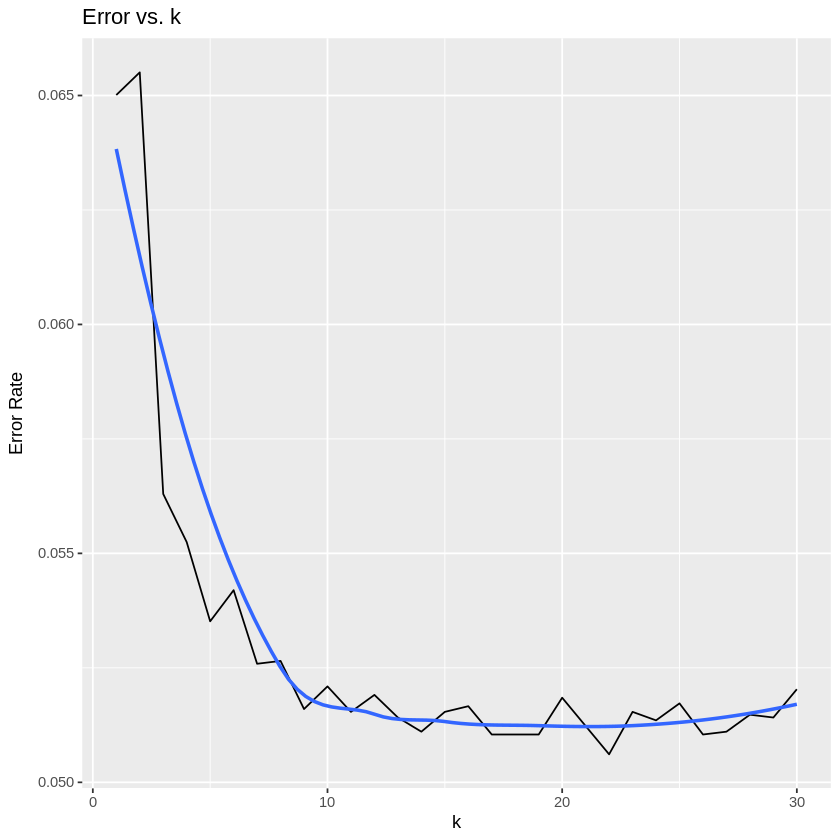

In [25]:
# INSERT CODE HERE
ggplot(output, aes(x = k, y = error)) +
  geom_line() +
  geom_smooth(se = FALSE) +
  labs(x = "k", y = "Error Rate") +
  ggtitle("Error vs. k")

Interpret your plot. What would you select as the best value of `k`? How much does this improve your test error?
> * Since the low k values (1-5) produce the highest error rates and the high k values (20-30) show a slight upwards trend, the best value of k appears to be somewhere around k = 10-15. This improves the test error to about 0.052 or 5.2%, so only about 0.2%.


-----
## 4. Standardizing predictors (2 points)

Because knn is based on distances between points, it is very sensitive to the scale of your variables. Looking at our predictor variables, we can see that `carat` and `depth` are orders of magnitude different in terms of scales. Maybe we can improve our fit even more by addressing this!

Below, use the `scale()` function to standardize your predictors. (Note that you don't need to standardize `price_bin`.)

Then, run your model a final time with your standardized predictors (just `carat` and `depth` still). Set `k` to the optimal value you determined in your plot above. Output the confusion matrix and error rate again.

In [27]:
set.seed(2023)
#INSERT CODE HERE
dia.scaled <- dia
dia.scaled[, c("carat", "depth")] <- scale(dia[, c("carat", "depth")])

train.scaled <- dia.scaled[dia.scaled$is.test == FALSE, ]
test.scaled <- dia.scaled[dia.scaled$is.test == TRUE, ]

train.X.scaled <- train.scaled[, c("carat", "depth")]
test.X.scaled <- test.scaled[, c("carat", "depth")]

knn.preds.scaled <- knn(train.X.scaled, test.X.scaled, train.scaled$price_bin, k = 12)

confusion_matrix.scaled <- table(Predicted = knn.preds.scaled, Actual = test.scaled$price_bin)
confusion_matrix.scaled

test.error.scaled <- mean(knn.preds.scaled != test.scaled$price_bin)
cat("Test Error:", test.error.scaled)

         Actual
Predicted    0    1
        0 9715  291
        1  531 5645

Test Error: 0.05079718

What impact did rescaling the data have on your error rate?
> * Rescaling brought the error down to 5.08%, improving the error rate even more than previously (with no scaling of k).


**DUE:** 11:59pm March 17, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *N/A*
>
>


**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.